
# GP Geo CV Result Analysis

Summarize restartable GP tuning results written by `GP Geo CV Tuning.ipynb`.


In [ ]:

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CWD = Path.cwd()
if CWD.name == "gridsearch":
    NOTEBOOK_DIR = CWD
elif (CWD / "gridsearch").exists() and CWD.name == "code":
    NOTEBOOK_DIR = CWD / "gridsearch"
elif (CWD / "code" / "gridsearch").exists():
    NOTEBOOK_DIR = CWD / "code" / "gridsearch"
else:
    NOTEBOOK_DIR = CWD
CODE_DIR = NOTEBOOK_DIR.parent
sys.path.append(str(CODE_DIR))

from eval_workflow import completed_gp_results, summarize_gp_results_by_config


In [ ]:

GRID_PATH = CODE_DIR / "gridsearch" / "gp_geo_stage1_grid.csv"
STAGE1_RESULT_DIR = CODE_DIR / "eval_results" / "gp_stage1"
STAGE2_RESULT_DIR = CODE_DIR / "eval_results" / "gp_stage2"
FINAL_GP_PATH = CODE_DIR / "eval_results" / "gp_final_holdout.csv"
FINAL_KNN_PATH = CODE_DIR / "eval_results" / "knn_final_holdout.csv"
LEGACY_RESULT_PATHS = sorted(NOTEBOOK_DIR.glob("gridsearch*_results.csv"))

current_grid = pd.read_csv(GRID_PATH)

def stage_summary(result_dir, expected_folds):
    # Historical analysis intentionally reads every per-fit CSV on disk.
    # Do not filter through the current grid; param_id has been reused across grids.
    results = completed_gp_results(result_dir)
    if results.empty:
        return results, pd.DataFrame()
    summary = summarize_gp_results_by_config(results)
    summary["complete"] = summary["n_folds"] == expected_folds
    return results, summary.sort_values(["complete", "mean_mse"], ascending=[False, True])

stage1_results, stage1_summary = stage_summary(STAGE1_RESULT_DIR, expected_folds=3)
stage2_results, stage2_summary = stage_summary(STAGE2_RESULT_DIR, expected_folds=5)



def load_legacy_gridsearch_results(paths):
    rows = []
    for path in paths:
        df = pd.read_csv(path).copy()
        df["source"] = path.name
        if "ls_ap" in df.columns:
            df["ap_form"] = "mult"
            df["os_ap"] = 0.0
        else:
            df["ap_form"] = "none"
            df["ls_ap"] = np.nan
            df["os_ap"] = 0.0
        rows.append(df)
    if not rows:
        return pd.DataFrame()
    cols = [
        "source", "mse", "ap_form", "ls_xy", "ls_z", "os_xyz", "ls_t", "os_t", "ls_ap", "os_ap"
    ]
    legacy = pd.concat(rows, ignore_index=True)
    return legacy[cols].sort_values("mse", na_position="last").reset_index(drop=True)

legacy_results = load_legacy_gridsearch_results(LEGACY_RESULT_PATHS)

len(stage1_results), len(stage2_results), len(legacy_results)


In [3]:

stage1_summary.head(20)


,param_id,mean_mse,std_mse,n_folds,mean_fit_elapsed,mean_predict_elapsed,mean_total_elapsed,ls_xy,ls_z,os_xyz,ls_t,os_t,ap_form,ls_ap,os_ap,complete
0,58,68.275078,NaN,3,4.388776,0.677469,5.181912,0.025,0.25,25,5,5,mult,1.0,0.0,True
1,197,71.201141,NaN,3,5.757858,1.417950,8.202715,0.025,0.50,50,50,5,mult,0.5,0.0,True
2,254,71.523947,11.768687,3,4.427262,0.685092,5.215899,0.035,0.25,25,50,0,mult,1.0,0.0,True
3,233,71.707359,11.528400,3,4.434857,0.721168,5.257794,0.035,0.25,20,50,0,mult,1.0,0.0,True
4,337,74.461014,9.398944,3,5.832455,1.409465,8.260758,0.035,0.50,20,50,0,mult,0.5,0.0,True
5,526,75.370689,9.010972,3,4.428857,0.860209,5.505624,0.040,0.50,10,50,0,mult,0.5,0.0,True
6,149,75.471844,11.481524,3,4.445472,0.683672,5.233431,0.025,0.50,25,50,0,mult,1.0,0.0,True
7,177,75.999012,11.438086,3,5.768993,1.348274,8.096626,0.025,0.50,35,50,5,mult,1.0,0.0,True
8,687,76.505299,10.957690,3,4.417977,0.865919,5.499265,0.050,0.25,25,5,5,mult,0.5,0.0,True
9,694,76.649979,9.117960,3,4.427934,0.852341,5.493963,0.050,0.25,35,50,0,mult,0.5,0.0,True


In [4]:

stage2_summary.head(20)


,param_id,mean_mse,std_mse,n_folds,mean_fit_elapsed,mean_predict_elapsed,mean_total_elapsed,ls_xy,ls_z,os_xyz,ls_t,os_t,ap_form,ls_ap,os_ap,complete
0,652,75.275160,12.802776,5,5.004282,0.858504,5.962578,0.050,0.25,20,50,0,mult,0.5,0.0,True
1,673,75.380469,10.591247,5,4.993980,0.856381,5.948882,0.050,0.25,25,50,0,mult,0.5,0.0,True
2,757,75.446855,10.993330,5,4.976200,0.994428,6.176215,0.050,0.50,20,50,0,mult,0.5,0.0,True
3,778,75.489424,10.470052,5,5.028089,0.834196,5.959694,0.050,0.50,25,50,0,mult,0.5,0.0,True
4,694,75.654773,9.933456,5,4.968491,1.002323,6.173333,0.050,0.25,35,50,0,mult,0.5,0.0,True
5,799,75.767210,9.733628,5,7.100335,1.786261,10.181582,0.050,0.50,35,50,0,mult,0.5,0.0,True
6,715,76.197754,9.269707,5,4.999203,0.828028,5.928146,0.050,0.25,50,50,0,mult,0.5,0.0,True
7,820,76.302446,9.007795,5,4.967582,0.834375,5.902109,0.050,0.50,50,50,0,mult,0.5,0.0,True
8,463,76.384195,13.432335,5,4.963652,0.823106,5.884452,0.040,0.25,25,50,0,mult,0.5,0.0,True
9,505,76.451039,12.566800,5,7.077327,1.813501,10.204632,0.040,0.25,50,50,0,mult,0.5,0.0,True


## Legacy Aggregate Runs

These are older `gridsearch*_results.csv` files. They are shown separately because they are aggregate holdout-style results, not restartable geo-CV fold results.


In [ ]:
legacy_results.head(25)


In [ ]:
if legacy_results.empty:
    legacy_run_counts = pd.DataFrame()
else:
    legacy_run_counts = (
        legacy_results.groupby(["source", "ap_form"], as_index=False)
        .agg(n_rows=("mse", "size"), n_completed=("mse", "count"), best_mse=("mse", "min"))
        .sort_values("best_mse")
    )
legacy_run_counts


In [5]:

def usable_summary():
    complete_stage2 = stage2_summary[stage2_summary["complete"]] if not stage2_summary.empty else pd.DataFrame()
    if not complete_stage2.empty:
        return "stage2", complete_stage2
    complete_stage1 = stage1_summary[stage1_summary["complete"]] if not stage1_summary.empty else pd.DataFrame()
    return "stage1", complete_stage1

active_stage, active_summary = usable_summary()
print(f"Using {active_stage} complete results for family bests")
active_summary.head(10)


Using stage2 complete results for family bests


,param_id,mean_mse,std_mse,n_folds,mean_fit_elapsed,mean_predict_elapsed,mean_total_elapsed,ls_xy,ls_z,os_xyz,ls_t,os_t,ap_form,ls_ap,os_ap,complete
0,652,75.275160,12.802776,5,5.004282,0.858504,5.962578,0.05,0.25,20,50,0,mult,0.5,0.0,True
1,673,75.380469,10.591247,5,4.993980,0.856381,5.948882,0.05,0.25,25,50,0,mult,0.5,0.0,True
2,757,75.446855,10.993330,5,4.976200,0.994428,6.176215,0.05,0.50,20,50,0,mult,0.5,0.0,True
3,778,75.489424,10.470052,5,5.028089,0.834196,5.959694,0.05,0.50,25,50,0,mult,0.5,0.0,True
4,694,75.654773,9.933456,5,4.968491,1.002323,6.173333,0.05,0.25,35,50,0,mult,0.5,0.0,True
5,799,75.767210,9.733628,5,7.100335,1.786261,10.181582,0.05,0.50,35,50,0,mult,0.5,0.0,True
6,715,76.197754,9.269707,5,4.999203,0.828028,5.928146,0.05,0.25,50,50,0,mult,0.5,0.0,True
7,820,76.302446,9.007795,5,4.967582,0.834375,5.902109,0.05,0.50,50,50,0,mult,0.5,0.0,True
8,463,76.384195,13.432335,5,4.963652,0.823106,5.884452,0.04,0.25,25,50,0,mult,0.5,0.0,True
9,505,76.451039,12.566800,5,7.077327,1.813501,10.204632,0.04,0.25,50,50,0,mult,0.5,0.0,True


In [ ]:

def best_rows_by_family(summary):
    if summary.empty:
        return pd.DataFrame()

    selectors = {
        "overall": np.ones(len(summary), dtype=bool),
        "no_time": summary["os_t"] == 0,
        "additive_ap": summary["ap_form"] == "add",
        "multiplicative_ap": summary["ap_form"] == "mult",
        "no_ap": summary["ap_form"] == "none",
    }
    rows = []
    for label, mask in selectors.items():
        subset = summary.loc[mask].sort_values(["mean_mse", "std_mse"], na_position="last")
        if subset.empty:
            continue
        row = subset.iloc[0].copy()
        row["selection"] = label
        rows.append(row)
    if not rows:
        return pd.DataFrame()
    cols = [
        "selection", "param_id_min", "param_id_max", "mean_mse", "std_mse",
        "n_folds", "n_result_rows",
        "ap_form", "ls_xy", "ls_z", "os_xyz", "ls_t", "os_t", "ls_ap", "os_ap",
        "mean_fit_elapsed", "mean_predict_elapsed",
    ]
    return pd.DataFrame(rows)[cols]

family_bests = best_rows_by_family(active_summary)
family_bests


In [7]:

if FINAL_GP_PATH.exists() or FINAL_KNN_PATH.exists():
    final_rows = []
    for path in [FINAL_GP_PATH, FINAL_KNN_PATH]:
        if path.exists():
            final_rows.append(pd.read_csv(path))
    final_results = pd.concat(final_rows, ignore_index=True)
else:
    final_results = pd.DataFrame()
final_results


,model,param_id,mse,n_train,n_test,fit_elapsed,predict_elapsed,jitter,ap_form,ls_xy,...,ls_t,os_t,ls_ap,os_ap,inner_geo5_mse,features__ap_scale,features__indoor_scale,knn__n_neighbors,knn__p,knn__weights
0,gp,652.0,73.173630,2064,553,7.942957,1.750814,0.00088,mult,0.05,...,50.0,0.0,0.5,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,knn,NaN,84.256256,2064,553,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,79.940137,1.0,0.5,54.0,1.0,distance


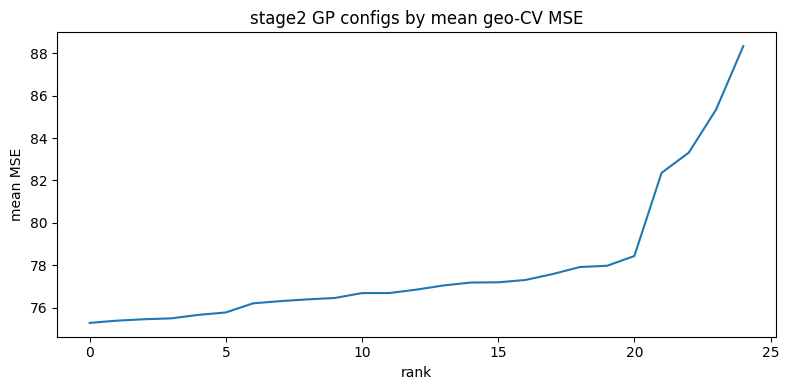

In [8]:

if not active_summary.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    active_summary.sort_values("mean_mse")["mean_mse"].reset_index(drop=True).plot(ax=ax)
    ax.set_title(f"{active_stage} GP configs by mean geo-CV MSE")
    ax.set_xlabel("rank")
    ax.set_ylabel("mean MSE")
    plt.tight_layout()
